# SRGAN Training for Calorimeter Super-Resolution

## GSoC 2026 - ML4SCI Evaluation Task

This notebook demonstrates training an SRGAN for super-resolving HEP calorimeter jet images.

**Dataset**: jet_RH1all (3-channel 125×125 images with LR/HR pairs)

**Goal**: Upscale low-resolution calorimeter images to match high-resolution ground truth while preserving physics (energy conservation).

In [15]:
!ls -lh /content/*.parquet

ls: cannot access '/content/*.parquet': No such file or directory


In [16]:
# Cell 1: Install required libraries and check GPU
!pip install -q pyarrow pandas matplotlib

import os
import torch
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

# Check GPU availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: You are on CPU. Go to Runtime > Change runtime type > T4 GPU")

device = 'cuda' if torch.cuda.is_available() else 'cpu'

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
# Cell 2: Load and verify the Parquet file structure
import pyarrow.parquet as pq
import numpy as np

PARQUET_FILE = "/content/drive/MyDrive/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet"

print(f"Reading file: {PARQUET_FILE}")
parquet_file = pq.ParquetFile(PARQUET_FILE)

print(f"Total samples (rows): {parquet_file.metadata.num_rows}")
print(f"Columns available: {parquet_file.schema.names}")

# Read just the first batch (100 rows) using PyArrow directly
first_batch = next(parquet_file.iter_batches(batch_size=100))

# FIX: Extract directly to Python lists, then safely stack them into numpy arrays.
# This completely prevents the Pandas "sequence" errors.
lr_list = first_batch.column('X_jets_LR').to_pylist()
hr_list = first_batch.column('X_jets').to_pylist()

lr_sample = np.stack([np.array(x, dtype=np.float32) for x in lr_list])
hr_sample = np.stack([np.array(x, dtype=np.float32) for x in hr_list])

# If the parquet file flattened the arrays during saving, reshape them back to 3D images
if len(lr_sample.shape) == 2:
    lr_sample = lr_sample.reshape(lr_sample.shape[0], 3, 64, 64)
if len(hr_sample.shape) == 2:
    hr_sample = hr_sample.reshape(hr_sample.shape[0], 3, 125, 125)

print(f"\nExtracted Batch Shapes:")
print(f"  LR (Low Res) Shape: {lr_sample.shape}")
print(f"  HR (High Res) Shape: {hr_sample.shape}")

Reading file: /content/drive/MyDrive/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet
Total samples (rows): 36272
Columns available: ['element', 'element', 'pt', 'm0', 'y']

Extracted Batch Shapes:
  LR (Low Res) Shape: (100, 3, 64, 64)
  HR (High Res) Shape: (100, 3, 125, 125)


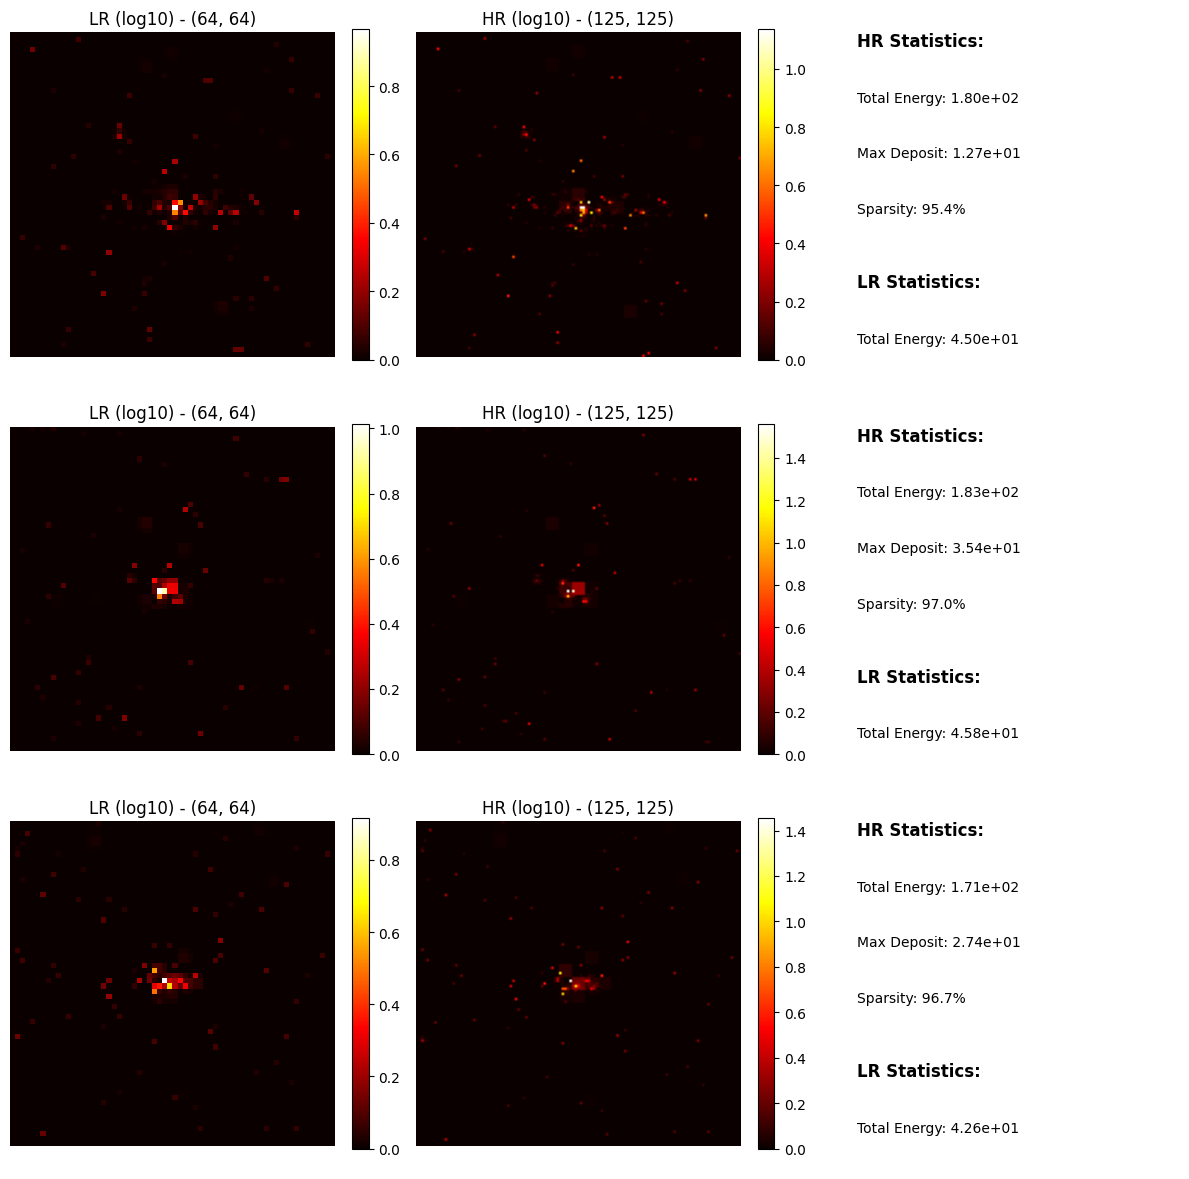

In [22]:
# Cell 3: Visualize the sparse jet data with Log-Scaling
import matplotlib.pyplot as plt

def visualize_jets(hr_data, lr_data, num_samples=3, cmap='hot'):
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))

    for i in range(num_samples):
        # Extract the single image array (already float32, no conversion needed)
        hr_arr = hr_data[i]
        lr_arr = lr_data[i]

        # Sum across the 3 channels to get total energy per pixel
        hr_img = hr_arr.sum(axis=0)
        lr_img = lr_arr.sum(axis=0)

        # Log scale for visualization (handle zeros safely)
        def safe_log(x):
            result = np.zeros_like(x)
            mask = x > 0
            result[mask] = np.log10(x[mask] + 1.0)
            return result

        hr_log = safe_log(hr_img)
        lr_log = safe_log(lr_img)

        # Plot LR
        ax = axes[i, 0]
        im = ax.imshow(lr_log, cmap=cmap)
        ax.set_title(f'LR (log10) - {lr_img.shape}')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

        # Plot HR
        ax = axes[i, 1]
        im = ax.imshow(hr_log, cmap=cmap)
        ax.set_title(f'HR (log10) - {hr_img.shape}')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)

        # Statistics
        ax = axes[i, 2]
        ax.text(0.1, 0.9, f"HR Statistics:", fontsize=12, fontweight='bold', transform=ax.transAxes)
        ax.text(0.1, 0.75, f"Total Energy: {hr_img.sum():.2e}", transform=ax.transAxes)
        ax.text(0.1, 0.60, f"Max Deposit: {hr_img.max():.2e}", transform=ax.transAxes)
        ax.text(0.1, 0.45, f"Sparsity: {(hr_img == 0).mean()*100:.1f}%", transform=ax.transAxes)
        ax.text(0.1, 0.25, f"\nLR Statistics:", fontsize=12, fontweight='bold', transform=ax.transAxes)
        ax.text(0.1, 0.10, f"Total Energy: {lr_img.sum():.2e}", transform=ax.transAxes)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize the first 3 samples
visualize_jets(hr_sample, lr_sample, num_samples=3)

In [26]:
# Cell 4: Hook up the Parquet dataloader to the SRGAN configuration
from parquet_dataset import create_dataloader
from srgan_calorimeter import CalorimeterGenerator, CalorimeterDiscriminator, SRGANTrainer

# === CONFIGURATION ===
CONFIG = {
    'parquet_file': PARQUET_FILE,
    'max_samples': 5000,      # Load 5000 samples to fit comfortably in Colab RAM

    # Model (Based on the parquet shapes we found: 64x64 -> 125x125)
    'in_channels': 3,
    'base_channels': 64,
    'num_residual_blocks': 8, # Reduced slightly for faster Colab prototyping
    'scale_factor': 2,        # 64 * 2 = 128 (cropped to 125 in the generator)
    'target_size': (125, 125),

    # Training Config
    'batch_size': 16,
    'pretrain_epochs': 5,     # 5 epochs of content-loss only (warming up the generator)
    'total_epochs': 25,       # 25 epochs total
    'lr_g': 1e-4,
    'lr_d': 1e-4,

    # Loss weights (Physics-informed)
    'content_weight': 1.0,
    'adversarial_weight': 0.001,
    'perceptual_weight': 0.0, # Disabled perceptual by default to save GPU memory

    'device': device,
}

print("Loading dataset into memory... (This might take a minute)")
# We use 'cached' mode to load a subset into RAM for fast training
train_loader = create_dataloader(
    parquet_paths=CONFIG['parquet_file'],
    batch_size=CONFIG['batch_size'],
    mode='cached',
    max_samples=CONFIG['max_samples'],
    normalize=True
)

val_loader = create_dataloader(
    parquet_paths=CONFIG['parquet_file'],
    batch_size=CONFIG['batch_size'],
    mode='cached',
    max_samples=500, # Just 500 samples for quick validation metrics
    normalize=True
)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Loading dataset into memory... (This might take a minute)
Train batches per epoch: 313
Validation batches: 32


In [27]:
# Cell 5: Initialize the SRGAN Generator and Discriminator
print("Initializing Models...")

generator = CalorimeterGenerator(
    in_channels=CONFIG['in_channels'],
    base_channels=CONFIG['base_channels'],
    num_residual_blocks=CONFIG['num_residual_blocks'],
    scale_factor=CONFIG['scale_factor'],
    target_size=CONFIG['target_size'] # Forces output to be exactly 125x125
).to(CONFIG['device'])

discriminator = CalorimeterDiscriminator(
    in_channels=CONFIG['in_channels'],
    base_channels=CONFIG['base_channels'],
).to(CONFIG['device'])

g_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)
d_params = sum(p.numel() for p in discriminator.parameters() if p.requires_grad)

print(f"Generator parameters: {g_params:,}")
print(f"Discriminator parameters: {d_params:,}")

Initializing Models...
Generator parameters: 807,747
Discriminator parameters: 5,342,593


In [28]:
# Cell 6: Execute the training!
print("Setting up Trainer...")

trainer = SRGANTrainer(
    generator=generator,
    discriminator=discriminator,
    train_loader=train_loader,
    val_loader=val_loader,
    dataset=train_loader.dataset,
    lr_g=CONFIG['lr_g'],
    lr_d=CONFIG['lr_d'],
    content_weight=CONFIG['content_weight'],
    adversarial_weight=CONFIG['adversarial_weight'],
    perceptual_weight=CONFIG['perceptual_weight'],
    pretrain_epochs=CONFIG['pretrain_epochs'],
    total_epochs=CONFIG['total_epochs'],
    device=CONFIG['device']
)

print("Starting Training Loop...")
history = trainer.train()

Setting up Trainer...
Starting Training Loop...
Starting Training on cuda...
Epoch 1/25 | G Loss: 5.1577 | D Loss: 0.0000 | Val PSNR: 27.38 dB
Epoch 2/25 | G Loss: 0.9077 | D Loss: 0.0000 | Val PSNR: 27.42 dB
Epoch 3/25 | G Loss: 0.6874 | D Loss: 0.0000 | Val PSNR: 28.15 dB
Epoch 4/25 | G Loss: 0.5876 | D Loss: 0.0000 | Val PSNR: 28.01 dB
Epoch 5/25 | G Loss: 0.4894 | D Loss: 0.0000 | Val PSNR: 27.79 dB
Epoch 6/25 | G Loss: 0.5520 | D Loss: 0.0089 | Val PSNR: 28.08 dB
Epoch 7/25 | G Loss: 0.4640 | D Loss: 0.0010 | Val PSNR: 29.12 dB
Epoch 8/25 | G Loss: 0.4377 | D Loss: 0.0005 | Val PSNR: 28.60 dB
Epoch 9/25 | G Loss: 0.3763 | D Loss: 0.0004 | Val PSNR: 28.97 dB
Epoch 10/25 | G Loss: 0.4228 | D Loss: 0.0003 | Val PSNR: 28.79 dB
Epoch 11/25 | G Loss: 0.4010 | D Loss: 0.0002 | Val PSNR: 28.93 dB
Epoch 12/25 | G Loss: 0.4134 | D Loss: 0.0002 | Val PSNR: 29.17 dB
Epoch 13/25 | G Loss: 0.3780 | D Loss: 0.0001 | Val PSNR: 29.38 dB
Epoch 14/25 | G Loss: 0.3618 | D Loss: 0.0002 | Val PSNR: 29.

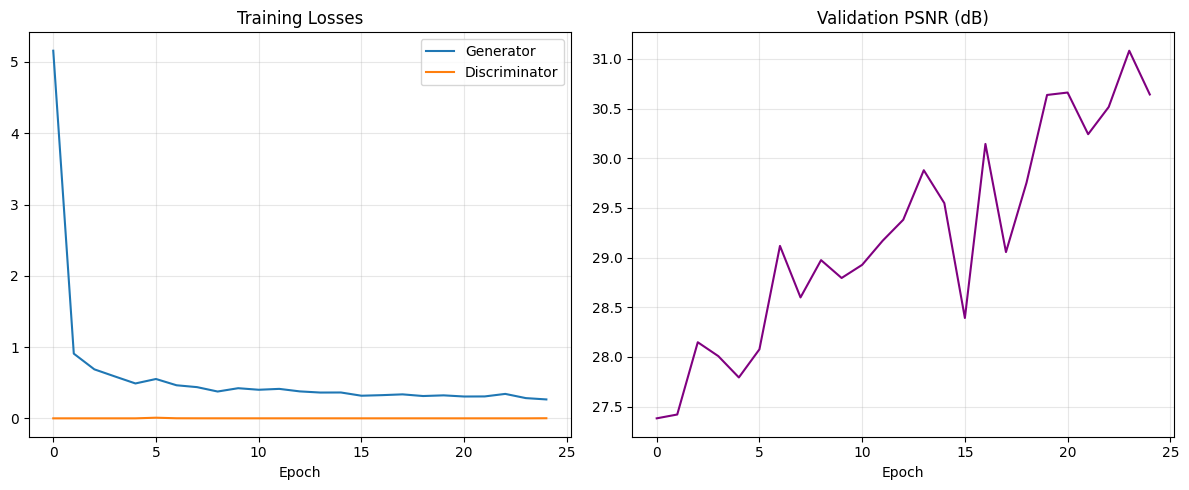

Model saved as 'gsoc_srgan_calorimeter.pth'! Download this file to your computer.


In [29]:
# Cell 7: Plot training history and save the model
def plot_training(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Loss curves
    axes[0].plot(history['train_g_loss'], label='Generator')
    if 'train_d_loss' in history and sum(history['train_d_loss']) > 0:
        axes[0].plot(history['train_d_loss'], label='Discriminator')
    axes[0].set_title('Training Losses')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # PSNR
    if 'val_psnr' in history and len(history['val_psnr']) > 0:
        axes[1].plot(history['val_psnr'], color='purple')
        axes[1].set_title('Validation PSNR (dB)')
        axes[1].set_xlabel('Epoch')
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training(history)

# Save the final generator weights so you can use them later!
torch.save(generator.state_dict(), 'gsoc_srgan_calorimeter.pth')
print("Model saved as 'gsoc_srgan_calorimeter.pth'! Download this file to your computer.")